In [1]:
# %matplotlib ipympl

In [2]:
import contextlib
import itertools
import multiprocessing as mp
import random
from pathlib import Path

import neurokit2 as nk
import numpy as np
import pandas as pd
import pyPPG
import pyPPG.example
import scipy.io
import scipy.signal
from matplotlib import pyplot as plt
from tqdm import notebook, tqdm

In [3]:
data_dir = Path('data')

In [4]:
images_dir = Path('images')

In [5]:
csv_dir = data_dir / 'csvs'

In [6]:
ppg_dir = data_dir / 'ppg'

In [7]:
pyppg_dir = data_dir / 'pyppg'

In [8]:
subjects_path = csv_dir / 'subjects.csv'

In [9]:
df_subjects = pd.read_csv(subjects_path)

In [10]:
df_subjects['patient_file'] = df_subjects.apply(lambda r: ppg_dir / f'p{r["subject_id"]:06d}_{r["segment_id"]}.mat', axis=1)

In [11]:
fs = 125

In [ ]:
def make_filter(design: str, wn: int):
    if design == 'cheby2':
        filt = scipy.signal.cheby2(4, 20, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    elif design == 'butter':
        filt = scipy.signal.butter(4, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    elif design == 'bessel':
        filt = scipy.signal.bessel(4, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    else:
        raise NotImplementedError
    return filt

In [13]:
target_num_cycles = 30

In [14]:
# discard first and last cycles from each signal
# check how many viable cycles each signal has
# settle on a number of cycles for all signals (maybe the minimum number of viable cycles)
# either: randomly sample cycles from signals with many cycles available
# or: sort cycles by quality and choose cycles with most quality
# get average cycle and try to detect points

In [ ]:
import pyPPG.preproc as PP
import pyPPG.fiducials as FP
from pyPPG import PPG, Fiducials
from pyPPG.datahandling import load_data

import numpy as np
import pandas as pd

In [ ]:
def ppg_example(data_path="", start_sig=0, end_sig=-1, channel="Pleth", filtering=False, fL=0.5000001, fH=12, order=4,
                smoothing=False, sm_wins={'ppg': 50, 'vpg': 10, 'apg': 10, 'jpg': 10}, savgol=False,
                peaks=None, onsets=None, correction=pd.DataFrame(), check_ppg_len=True):

    # Loading a raw PPG signal
    signal = load_data(data_path=data_path, fs=fs, start_sig=start_sig, end_sig=end_sig, channel=channel, use_tk=True, print_flag=False)

    # Initialise the filters
    prep = PP.Preprocess(fL=fL, fH=fH, order=order, sm_wins=sm_wins)

    # Filter and calculate the PPG, PPG', PPG", and PPG'" signals
    signal.fs = signal.fs.item() if isinstance(signal.fs, np.ndarray) else signal.fs
    signal.filtering = filtering
    signal.fL = fL
    signal.fH = fH
    signal.order = order
    signal.sm_wins = sm_wins
    signal.ppg, signal.vpg, signal.apg, signal.jpg = prep.get_signals(s=signal)

    if smoothing:
        win = round(fs * sm_wins['ppg']/1000)
        b = 1 / win * np.ones(win)
        signal.ppg = scipy.signal.filtfilt(b, 1, signal.ppg)

    if savgol:
        signal.vpg = scipy.signal.savgol_filter(signal.ppg, 3, 2, deriv=1)
        signal.apg = scipy.signal.savgol_filter(signal.vpg, 3, 2, deriv=2)
        signal.jpg = scipy.signal.savgol_filter(signal.apg, 3, 2, deriv=3)

    # Initialise the correction for fiducial points
    corr_on = ['on', 'dn', 'dp', 'v', 'w', 'f']
    correction.loc[0, corr_on] = True
    signal.correction=correction

    # Create a PPG class
    s = PPG(s=signal, check_ppg_len=check_ppg_len)

    # Get Fiducial points
    fpex = FP.FpCollection(s=s)
    fiducials = fpex.get_fiducials(s, peaks, onsets)
    fp = Fiducials(fp=fiducials)

    return s, fp

100%|██████████| 34/34 [00:03<00:00, 10.66it/s]


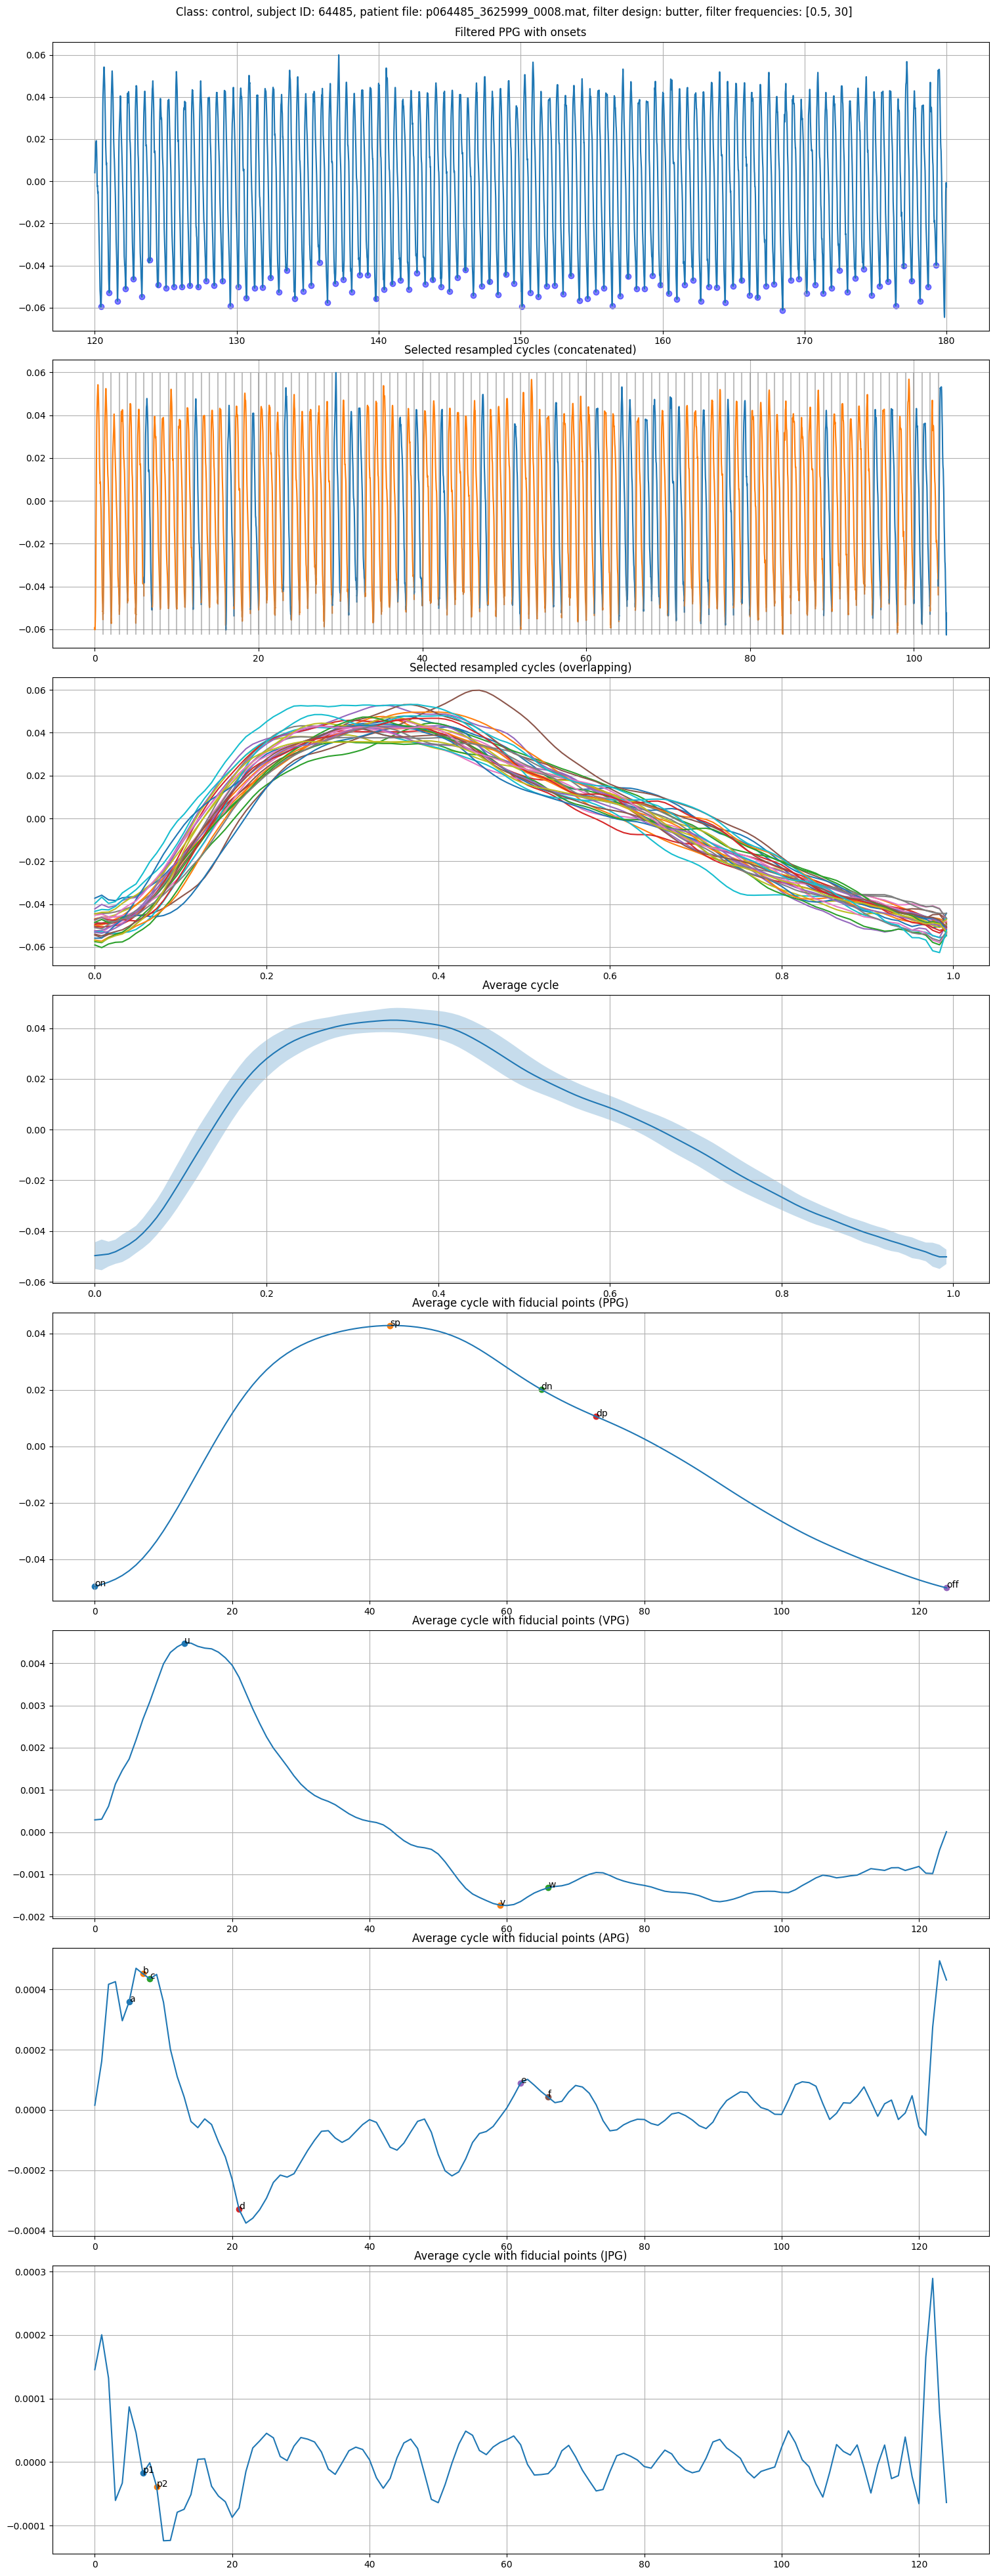

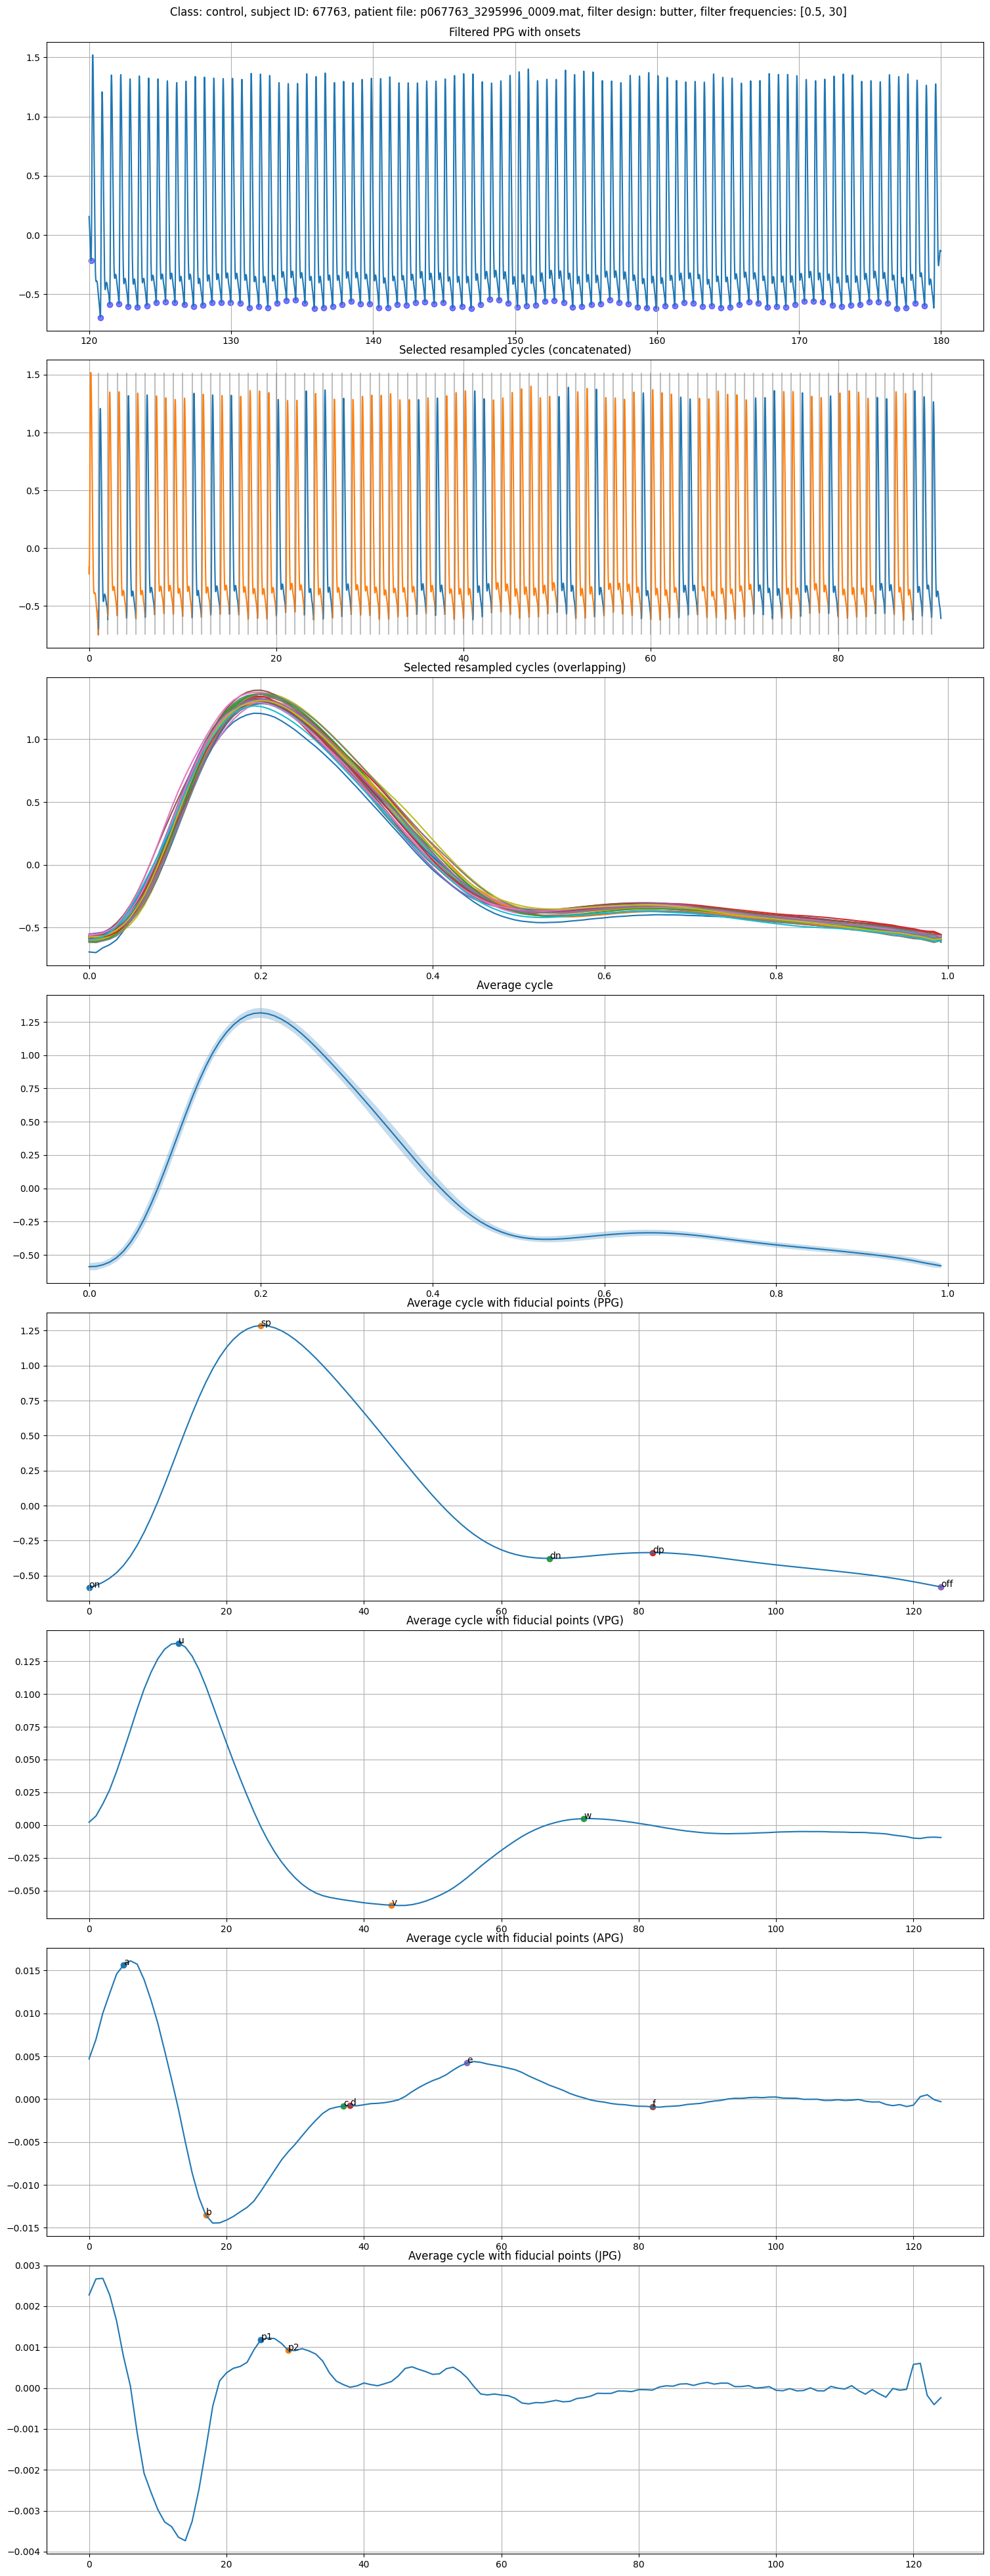

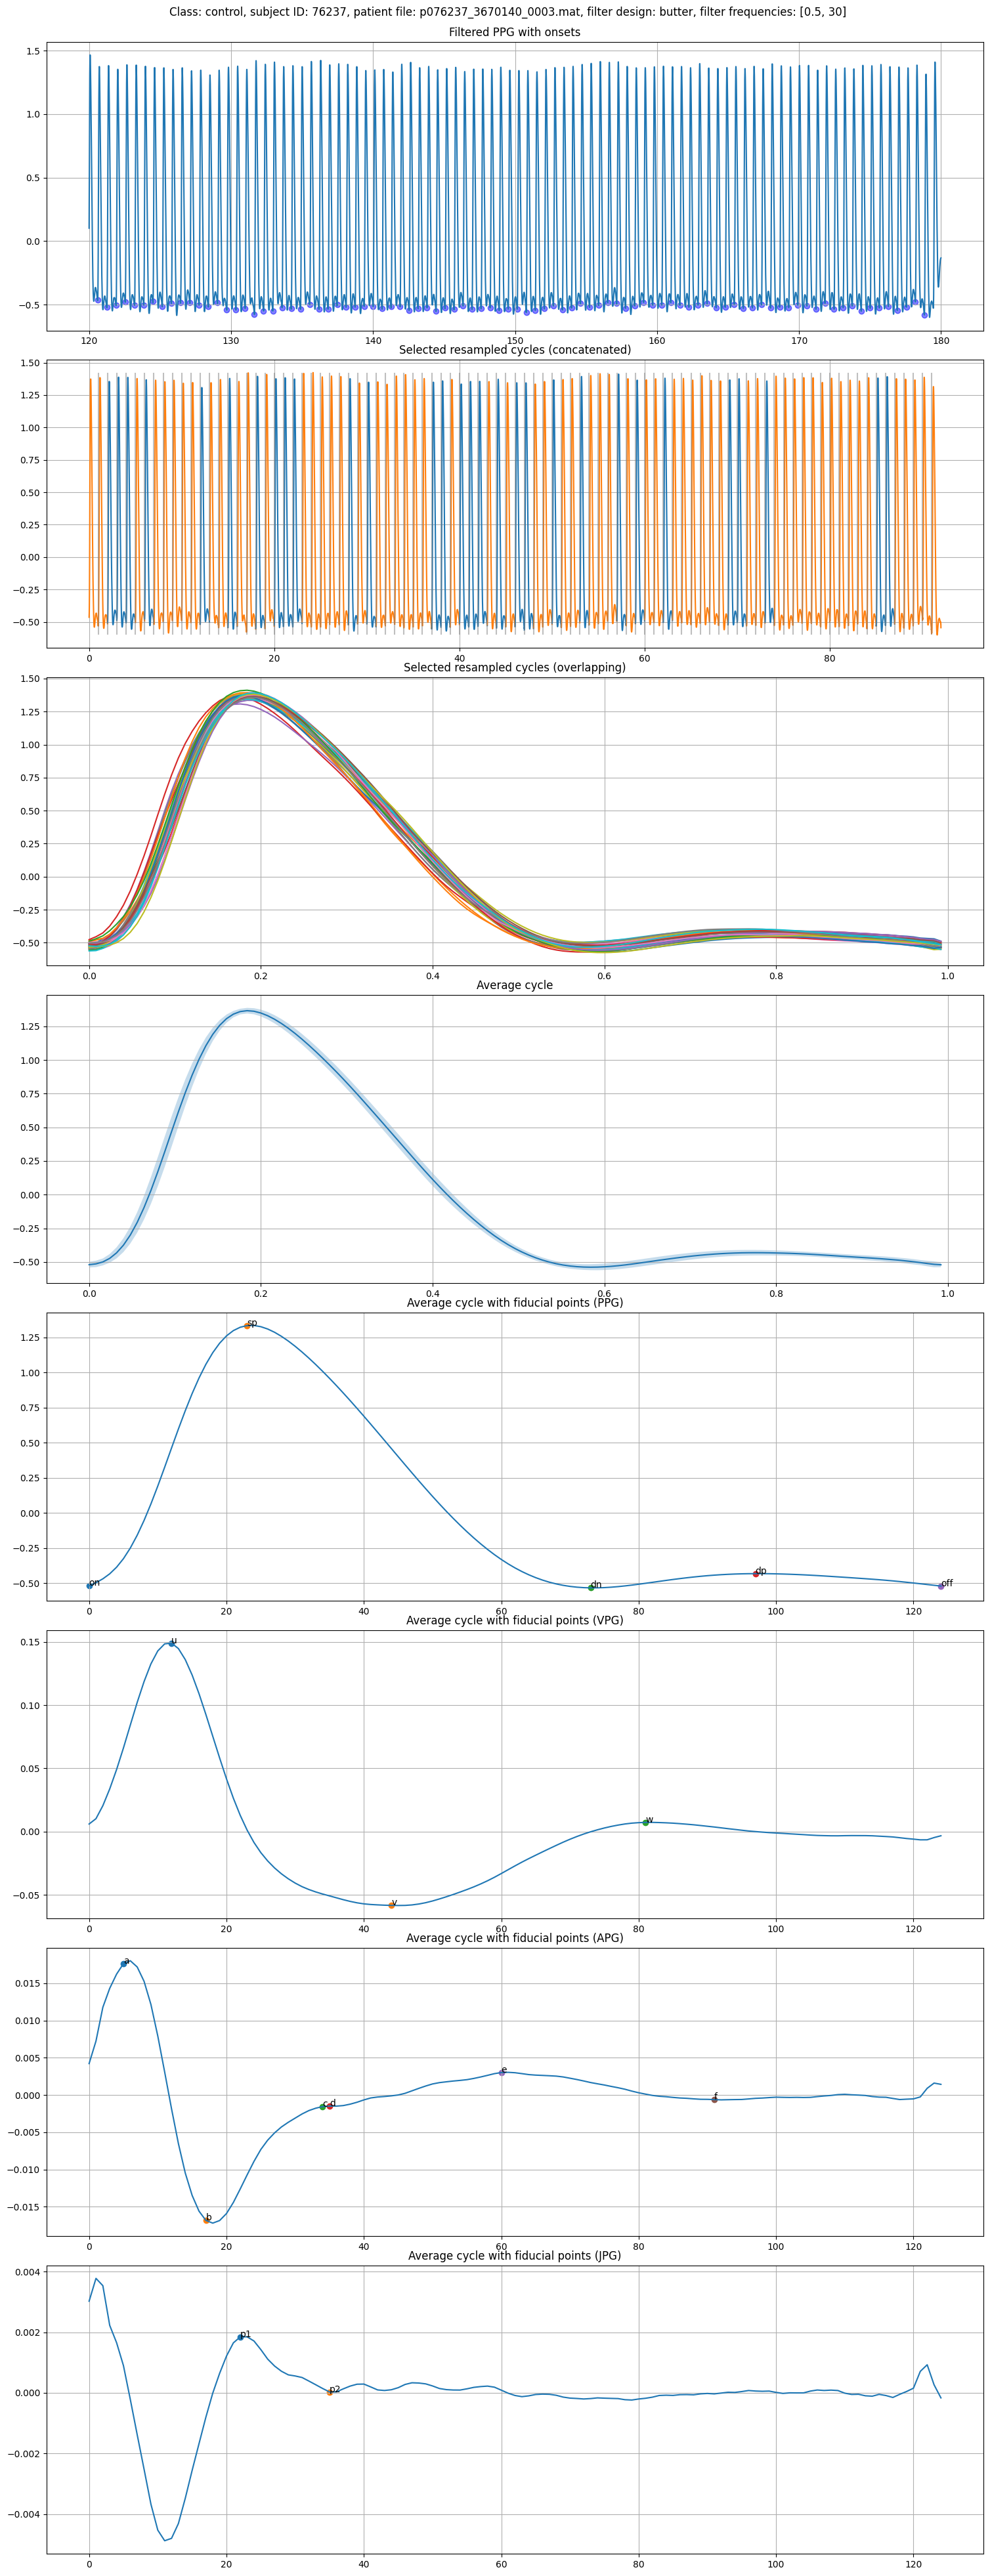

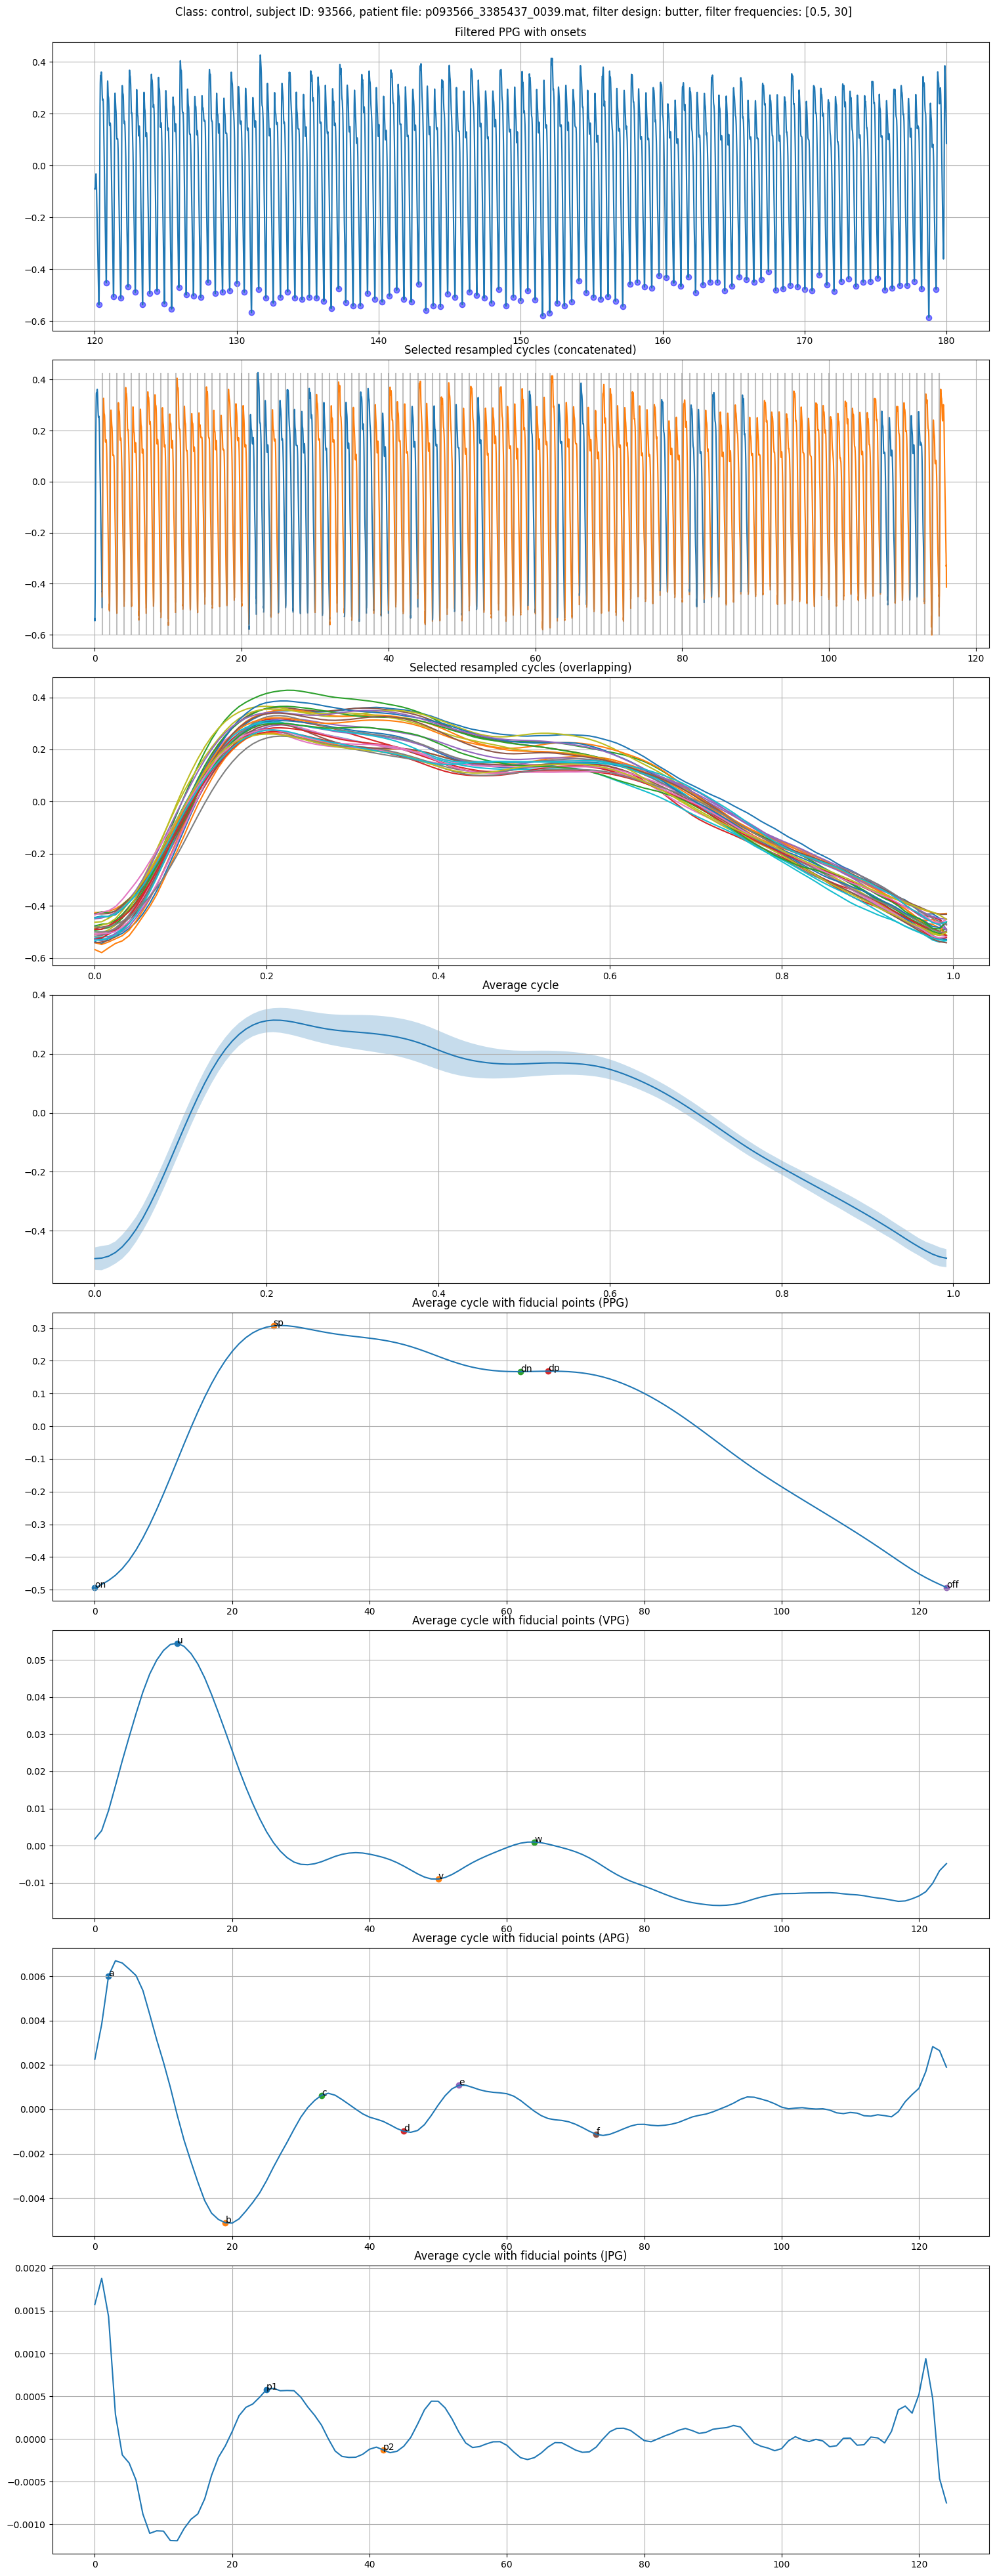

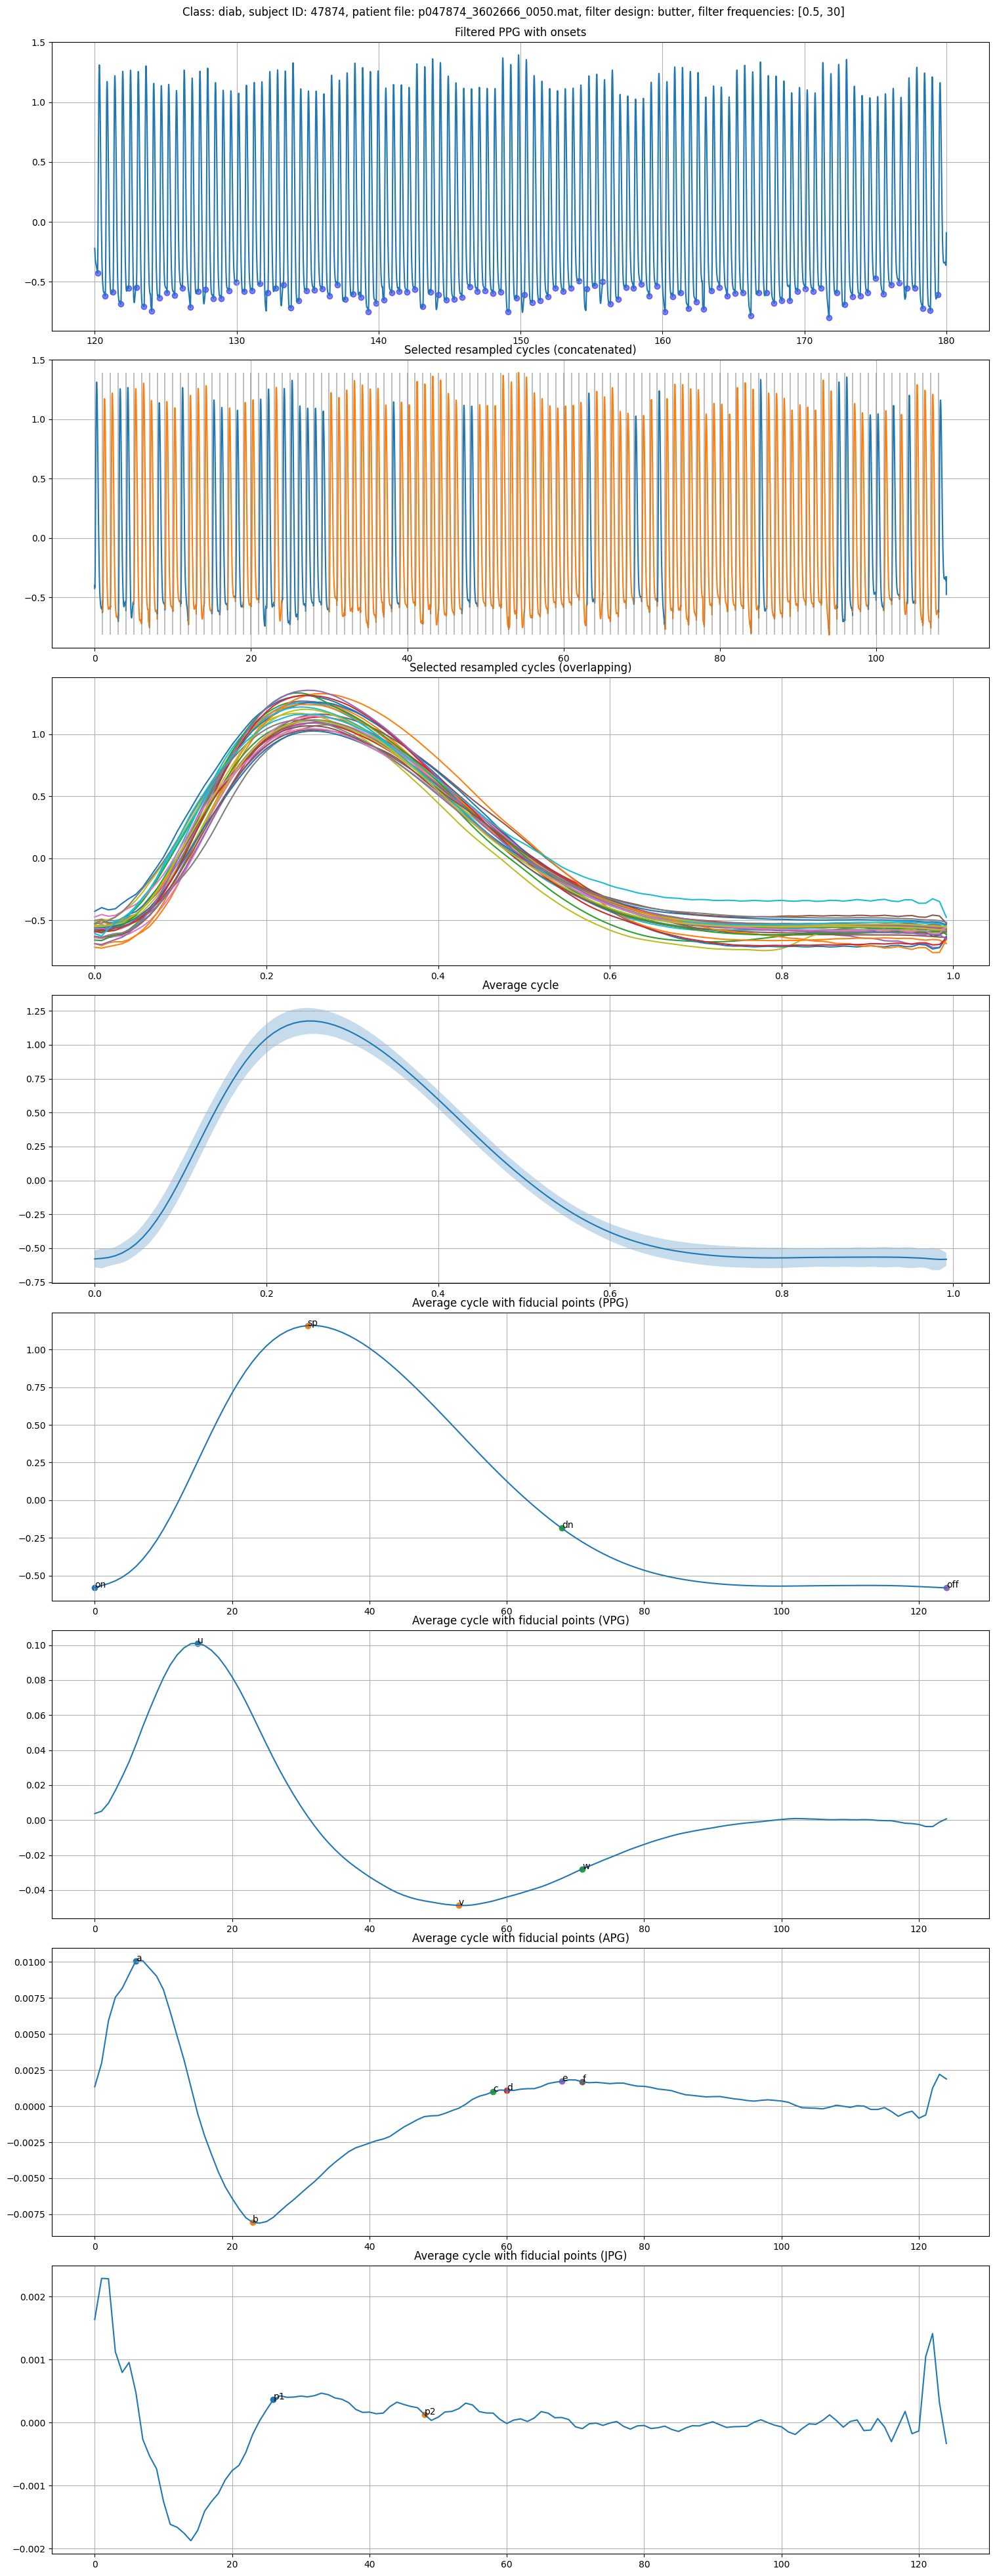

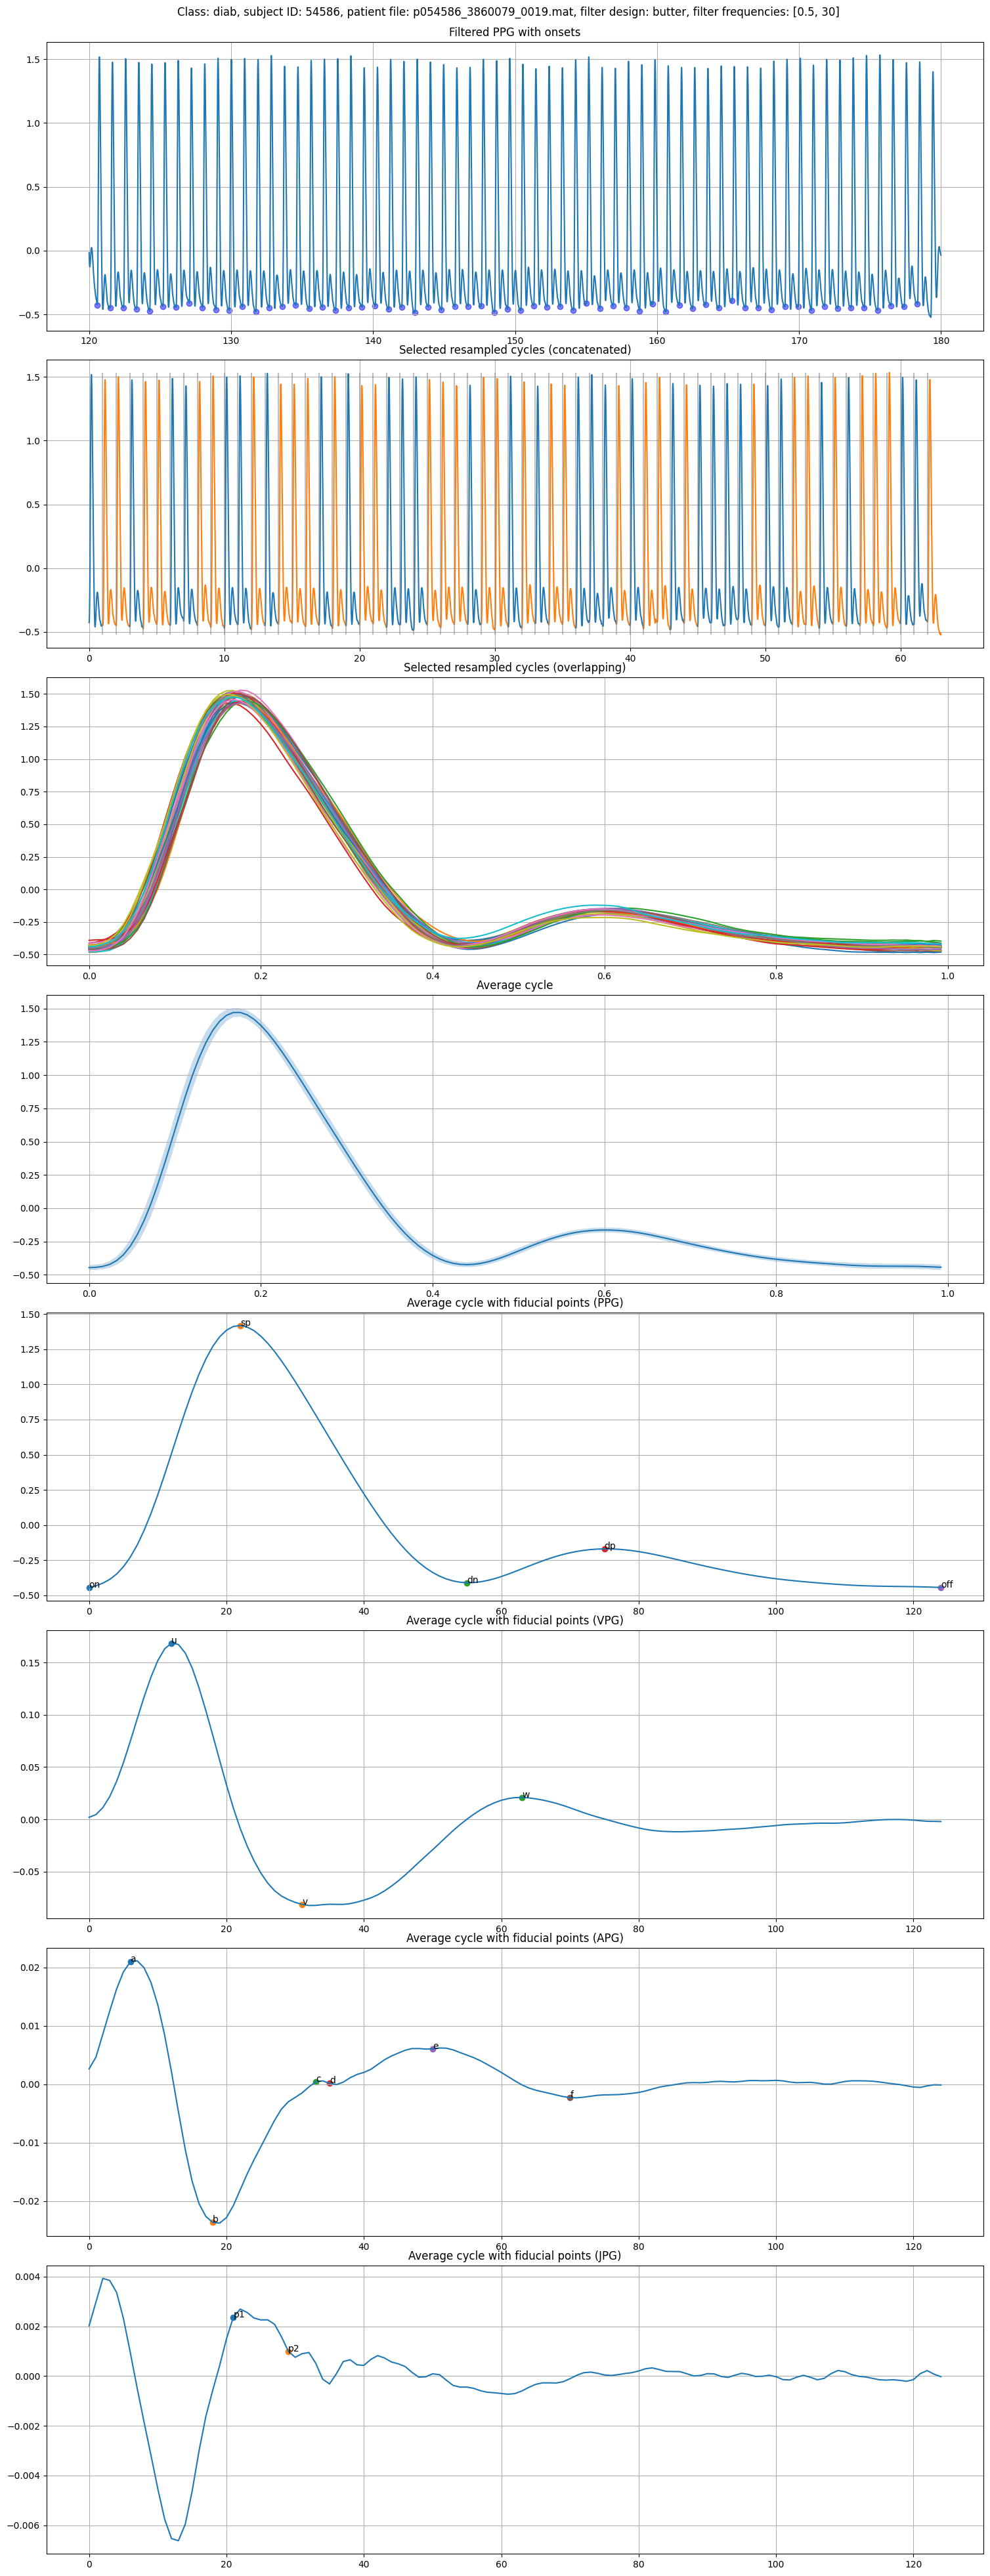

In [ ]:
# designs = ['cheby2', 'butter', 'bessel']
designs = ['butter']

# wns = [10, 15, 20, 25, 30, 35, [0.5, 10], [0.5, 12], [0.5, 15], [0.5, 20], [0.5, 25], [0.5, 30], [0.5, 35], [0.1, 30]]
# wns = [[0.1, 30], [0.5, 12]]
wns = [[0.5, 30]]

# subject_records = list(df_subjects.loc[:1, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# subject_records = list(df_subjects.sample(1, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
subject_records = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(subject_records, designs, wns))):

    #
    # select, load and filter signal
    #

    if subject_id not in [67763, 54586, 47874, 93566, 64485, 76237]:
        continue

    mat = scipy.io.loadmat(patient_file)

    t = mat['time'].squeeze()
    ppg_raw = mat['data'].squeeze()

    s0 = 2 * 60 * fs
    s1 = s0 + 1 * 60 * fs
    t = t[s0:s1]
    ppg_raw = ppg_raw[s0:s1]

    filt = make_filter(design, wn)
    ppg_filt = scipy.signal.sosfiltfilt(filt, ppg_raw)

    #
    # load annotated peaks and onsets
    #

    points_path = csv_dir / 'points.csv'

    df_records = pd.read_csv(
        points_path,
        dtype={
            'subject_id': pd.Int64Dtype(),
            'signal_name': pd.StringDtype(),
            'x': pd.Float64Dtype(),
            'y': pd.Float64Dtype(),
            'label': pd.Int64Dtype(),
        }
    )

    df_records = df_records.sort_values(['subject_id', 'signal_name', 'label', 'x'])

    df_records = df_records.set_index(['subject_id', 'signal_name', 'label'])

    ppg_peaks = (df_records.loc[(subject_id, 'PLETH', 1), 'x'] * 125).round().astype(int).to_numpy()

    ppg_onsets = (df_records.loc[(subject_id, 'PLETH', 3), 'x'] * 125).round().astype(int).to_numpy()

    #
    # get peaks and cycles from filtered signal
    #

    df_cycles = pd.DataFrame(itertools.pairwise(ppg_onsets), columns=['on', 'off'])

    fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(15, 40))
    axes: tuple[plt.Axes]
    fig.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    axes[0].plot(t, ppg_filt)
    axes[0].scatter(t[df_cycles['on']], ppg_filt[df_cycles['on']], color='blue', alpha=0.5)
    axes[0].set_title('Filtered PPG with onsets')
    axes[0].grid()

    #
    # get signal quality, normalize cycle length, filter cycles, get average cycle signal and rebuild signal
    #

    ppg_quality_tm = nk.ppg.ppg_quality(ppg_filt, peaks=ppg_peaks, sampling_rate=fs, method='templatematch')
    ppg_quality_ho = nk.ppg.ppg_quality(ppg_filt, peaks=ppg_peaks, sampling_rate=fs, method='ho2025')

    # selected_cycles = df_cycles.sample(min_num_cycles, random_state=0)
    cycles = df_cycles

    resampled_cycle_signals = []
    resampled_cycle_qualities_tm = []
    resampled_cycle_qualities_ho = []
    # resampled_cycles = []
    for on, off in cycles.itertuples(index=False):
        resampled_cycle_signal = scipy.signal.resample(ppg_filt[on:off], fs)
        resampled_cycle_signals.append(resampled_cycle_signal)
        resampled_cycle_quality_tm = np.mean(scipy.signal.resample(ppg_quality_tm[on:off], fs))
        resampled_cycle_qualities_tm.append(resampled_cycle_quality_tm)
        resampled_cycle_quality_ho = np.mean(scipy.signal.resample(ppg_quality_ho[on:off], fs))
        resampled_cycle_qualities_ho.append(resampled_cycle_quality_ho)
        # resampled_cycles.append((resampled_cycle_signal, resampled_cycle_quality_tm, resampled_cycle_quality_ho))
    resampled_cycle_signals = np.array(resampled_cycle_signals)
    resampled_cycle_qualities_tm = np.array(resampled_cycle_qualities_tm)
    resampled_cycle_qualities_ho = np.array(resampled_cycle_qualities_ho)
    # resampled_cycles = np.array(resampled_cycles)

    # TODO: remove cycles where points are not being detected

    # TODO: apply multiple quality filters and sorts

    sorted_idxs = np.argsort(resampled_cycle_qualities_tm)

    selected_cond = sorted_idxs < target_num_cycles

    selected_cycle_signals = resampled_cycle_signals[selected_cond]

    num_cycles = resampled_cycle_signals.shape[0]

    for c, (signal, selected) in enumerate(zip(resampled_cycle_signals, selected_cond)):
        time = np.linspace(c, (c + 1) - 1 / fs, fs)
        axes[1].plot(time, signal, color='C0' if selected else 'C1')
    axes[1].vlines(np.arange(1, num_cycles, 1), np.min(resampled_cycle_signals), np.max(resampled_cycle_signals), color='grey', alpha=0.5)
    axes[1].set_title('Selected resampled cycles (concatenated)')
    axes[1].grid()

    cycle_signal_time = np.linspace(0, 1 - 1 / fs, fs)

    for signal in selected_cycle_signals:
        axes[2].plot(cycle_signal_time, signal)
    axes[2].set_title('Selected resampled cycles (overlapping)')
    axes[2].grid()

    cycle_signal_mean = np.mean(selected_cycle_signals, axis=0)
    cycle_signal_std = np.std(selected_cycle_signals, axis=0)

    axes[3].plot(cycle_signal_time, cycle_signal_mean)
    axes[3].fill_between(cycle_signal_time, cycle_signal_mean - cycle_signal_std, cycle_signal_mean + cycle_signal_std, alpha=0.25)
    # axes[3].errorbar(cycle_signal_time, cycle_signal_mean, cycle_signal_std)
    axes[3].set_title('Average cycle')
    axes[3].grid()

    #
    # get fiducial points from mean cycle
    #

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    nc = 1
    # cycle_signal_mean_repeated = np.tile(cycle_signal_mean[:-1], nc)
    cycle_signal_mean_repeated = np.tile(cycle_signal_mean, nc)
    scipy.io.savemat((pyppg_dir / '2+1_mean' / signal_file).as_posix(), {'Fs': fs, 'Data': cycle_signal_mean_repeated})

    cycle_signal_peak = np.argmax(cycle_signal_mean)
    peaks = np.arange(cycle_signal_peak, cycle_signal_peak + (nc + 1) * 125, 125)
    # onsets = np.append(np.arange(0, nc * 125, 125), nc * 125 - 1)
    onsets = np.arange(0, (nc + 1) * 125, 125)
    onsets[-1] -= 1

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp = ppg_example(
            data_path=(pyppg_dir / '2+1_mean' / signal_file).as_posix(),
            fs=125,
            check_ppg_len=False,
            peaks=peaks,
            onsets=onsets,
            smoothing=True,
            # savgol=True
            # filtering=True,
            # fL=0.5,
            # fH=12
        )

    t_pts = fp.get_fp()

    # axes[4].plot(cycle_signal_mean)
    axes[4].plot(s.ppg)
    for c in t_pts.index:
        for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
            if not pd.isna(t_pts[m][c]):
                axes[4].scatter(t_pts[m][c], s.ppg[t_pts[m][c]], color=f'C{n}')
                axes[4].annotate(m, (t_pts[m][c], s.ppg[t_pts[m][c]]))
    axes[4].set_title('Average cycle with fiducial points (PPG)')
    axes[4].grid()

    axes[5].plot(s.vpg)
    for c in t_pts.index:
        for n, m in enumerate(['u', 'v', 'w']):
            if not pd.isna(t_pts[m][c]):
                axes[5].scatter(t_pts[m][c], s.vpg[t_pts[m][c]], color=f'C{n}')
                axes[5].annotate(m, (t_pts[m][c], s.vpg[t_pts[m][c]]))
    axes[5].set_title('Average cycle with fiducial points (VPG)')
    axes[5].grid()

    axes[6].plot(s.apg)
    for c in t_pts.index:
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            if not pd.isna(t_pts[m][c]):
                axes[6].scatter(t_pts[m][c], s.apg[t_pts[m][c]], color=f'C{n}')
                axes[6].annotate(m, (t_pts[m][c], s.apg[t_pts[m][c]]))
    axes[6].set_title('Average cycle with fiducial points (APG)')
    axes[6].grid()

    axes[7].plot(s.jpg)
    for c in t_pts.index:
        for n, m in enumerate(['p1', 'p2']):
            if not pd.isna(t_pts[m][c]):
                axes[7].scatter(t_pts[m][c], s.jpg[t_pts[m][c]], color=f'C{n}')
                axes[7].annotate(m, (t_pts[m][c], s.jpg[t_pts[m][c]]))
    axes[7].set_title('Average cycle with fiducial points (JPG)')
    axes[7].grid()

    # break

In [ ]:
# subject_records = list(df_subjects.loc[:1, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# subject_records = list(df_subjects.sample(1, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
subject_records = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(subject_records, designs, wns))):

    #
    # select, load and filter signal
    #

    if subject_id not in [67763, 54586, 47874, 93566, 64485, 76237]:
        continue

    mat = scipy.io.loadmat(patient_file)

    t = mat['time'].squeeze()
    ppg_raw = mat['data'].squeeze()

    s0 = 2 * 60 * fs
    s1 = s0 + 1 * 60 * fs
    t = t[s0:s1]
    ppg_raw = ppg_raw[s0:s1]

    filt = make_filter(design, wn)
    ppg_filt = scipy.signal.sosfiltfilt(filt, ppg_raw)

    #
    # load annotated peaks and onsets
    #

    points_path = csv_dir / 'points.csv'

    df_records = pd.read_csv(
        points_path,
        dtype={
            'subject_id': pd.Int64Dtype(),
            'signal_name': pd.StringDtype(),
            'x': pd.Float64Dtype(),
            'y': pd.Float64Dtype(),
            'label': pd.Int64Dtype(),
        }
    )

    df_records = df_records.sort_values(['subject_id', 'signal_name', 'label', 'x'])

    df_records = df_records.set_index(['subject_id', 'signal_name', 'label'])

    ppg_peaks = (df_records.loc[(subject_id, 'PLETH', 1), 'x'] * 125).round().astype(int).to_numpy()

    ppg_onsets = (df_records.loc[(subject_id, 'PLETH', 3), 'x'] * 125).round().astype(int).to_numpy()

    #
    # get peaks and cycles from filtered signal
    #

    df_cycles = pd.DataFrame(itertools.pairwise(ppg_onsets), columns=['on', 'off'])

    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 25))
    axes: tuple[plt.Axes]
    fig.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    axes[0].plot(t, ppg_filt)
    axes[0].scatter(t[df_cycles['on']], ppg_filt[df_cycles['on']], color='blue', alpha=0.5)
    axes[0].set_title('Filtered PPG with onsets')
    axes[0].grid()

    #
    # get fiducial points from mean cycle
    #

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    scipy.io.savemat((pyppg_dir / '2+1' / signal_file).as_posix(), {'Fs': fs, 'Data': ppg_filt})

    peaks = ppg_peaks

    onsets = ppg_onsets[:-1]

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp = ppg_example(
            data_path=(pyppg_dir / '2+1' / signal_file).as_posix(),
            fs=125,
            # check_ppg_len=False,
            peaks=peaks,
            onsets=onsets,
            smoothing=True,
            # savgol=True
            # filtering=True,
            # fL=0.5,
            # fH=12
        )

    t_pts = fp.get_fp()

    # axes[4].plot(cycle_signal_mean)
    axes[1].plot(s.ppg)
    for c in t_pts.index:
        for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
            if not pd.isna(t_pts[m][c]):
                axes[1].scatter(t_pts[m][c], s.ppg[t_pts[m][c]], color=f'C{n}')
    axes[1].set_title('Average cycle with fiducial points')
    axes[1].grid()

    axes[2].plot(s.vpg)
    for c in t_pts.index:
        for n, m in enumerate(['u', 'v', 'w']):
            if not pd.isna(t_pts[m][c]):
                axes[2].scatter(t_pts[m][c], s.vpg[t_pts[m][c]], color=f'C{n}')
    axes[2].set_title('Average cycle with fiducial points')
    axes[2].grid()

    axes[3].plot(s.apg)
    for c in t_pts.index:
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e']):
            if not pd.isna(t_pts[m][c]):
                axes[3].scatter(t_pts[m][c], s.apg[t_pts[m][c]], color=f'C{n}')
    axes[3].set_title('Average cycle with fiducial points')
    axes[3].grid()

    axes[4].plot(s.jpg)
    for c in t_pts.index:
        for n, m in enumerate(['p1', 'p2']):
            if not pd.isna(t_pts[m][c]):
                axes[4].scatter(t_pts[m][c], s.jpg[t_pts[m][c]], color=f'C{n}')
    axes[4].set_title('Average cycle with fiducial points')
    axes[4].grid()

    break